## 线性回归与逻辑回归

### 线性单元


深度学习又是机器学习的一大分支，大部分机器学习问题都可以划分为监督学习（Supervised Learning）和无监督学习（Unsupervised Learning）两类：

- 监督学习：给定的数据集中已经包含了正确的输出结果，希望机器能够根据这些数据集学习一个模型，使模型能够对任意的输入，对其对应的输出做出一个好的预测。
- 无监督学习：给定的数据集中不包含任何输出结果，希望机器通过算法自行分析而得出结果。

机器学习中两大最基础的任务--分类（Classification）和回归（Regression），都属于监督学习，其对比如下：

| 特征 | 分类问题 (Classification) | 回归问题 (Regression) |
| --- | --- | --- |
| **输出类型** | **离散型**（类别、标签） | **连续型**（数字、量） |
| **回答的问题** | “它是哪一类？” | “数值是多少？” |
| **案例** | 垃圾邮件识别、人脸识别、手写数字识别 | 房价预测、气温预测、股票走势 |

而线性单元（Linear Unit）则是神经网络中最基本、最简单的“原子”单元。如果把深度学习模型比作一座大厦，线性单元就是其中最基础的一块砖。其数学表达式非常简单：

$$y = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$$

或者写成向量形式：

$$y = \mathbf{w}^T\mathbf{x} + b$$

它包含以下特性：
* **输出范围：** 线性单元的输出 $y$ 是一个连续的实数，范围是从 $-\infty$ 到 $+\infty$。
* **预测目标：** 其目标是预测一个**连续的数值**（比如房价、气温、股票价格）。
* **匹配度：** 这种“输入什么，加权后就输出什么”的特性，让它能直接拟合连续的函数曲线。

基于线性单元这种特性，单纯的线性单元只适用于回归问题，要用它来解决分类问题，必须给它加一个激活函数（Activation Function），例如：

* 逻辑回归（Logistic Regression）：在线性单元后面套一个 **Sigmoid** 函数。它把原本 $-\infty$ 到 $+\infty$ 的输出映射到 $(0, 1)$ 之间。
* 多分类（Softmax）：在多个线性单元后面套一个 **Softmax** 函数，用来输出每个类别的概率。

第一讲里面的感知机里，其实就已经用到了线性单元：

![感知机](https://ask.qcloudimg.com/http-save/yehe-1332428/gb0jpekzg2.jpeg?imageView2/2/w/2560/h/7000)

而这个最简单的感知机是用了阶跃函数来作为激活函数，从而把前面线性单元的输出映射为`0`或`1`：

$$f(z)=\begin{cases}1\qquad z>0\\0\qquad otherwise\end{cases}$$



### 线性回归

这里通过解决如下问题，来学习机器学习中最基础的线性回归（linear regression）模型。

假如收集到如下“房价”因“房子面积”的变化而变化的数据：

![房价预测数据](https://raw.githubusercontent.com/Hugsy19/Picbed/master/img/20210411170315.png)

要通过这些数据解决一个“房价预测”问题，即由任意给定的“房子面积”预测出相应的“房价”。显然，这是一个监督学习下的回归问题。

要解决该问题，我们就要根据已有的数据建立合适的机器学习模型。

#### 符号约定

这里首先对一些后面将反复用到的符号的含义约定如下：
* $m$：训练样本（training example）的数量
* $x^{(i)}$：第$i$个输入变量（即“训练样本”）
* $y^{(i)}$：第$i$个输出变量（也称“目标变量”）
* $(x^{(i)},y^{(i)})$：第$i$个训练样本，当$i = 1，\cdots , m$时称为一个训练集（training set）
* $X$：输入空间（input space，也称“样本空间”）
* $Y$：输出空间（output space，也称“标记空间”）
* $\theta_i$：要通过学习得到的第$i$个参数

“房价预测”问题中，共有$m$个训练样本，输入变量$x$为“房子面积”，输出变量$y$是“真实房价”，且$x^{(1)} = 2104,y^{(1)} = 460$，$(x^{(1)}，y^{(1)})$组成第一个训练样本，$x^{(1)},\cdots,x^{(m)}$形成样本空间$X$，$y^{(1)},\cdots,y^{(m)}$则形成标记空间$Y$。


#### 假设函数
在解决监督学习问题，我们的目标是：给定一个训练集，希望从中学得一个由$X$到$Y$的**假设函数（hypothesis function）**$h(x)$，使得对于任意的输入$x$，都能通过$h(x)$准确预测出相应的输出$y$，如下图所示：

![监督学习](https://raw.githubusercontent.com/Hugsy19/Picbed/master/img/20210411170329.png)

问题中，如果将假设函数简单地设定为一个线性函数：$$h_\theta(x) = \theta_0 + \theta_1x $$
那么我们的目标，就是根据给定的训练样本，获得假设函数中的两个参数值，而获得能过够通过房子面积预测房价的线性回归模型。

![线性回归模型](https://raw.githubusercontent.com/Hugsy19/Picbed/master/img/20210411170342.png)

#### 成本函数
在模型的训练过程中，我们需要综合所有的训练样本，训练出表现最优的模型。对于习得的一个假设函数$h(x)$，我们用成本函数（cost function）来评估其预测的准确度，且评估的过程，是将假设函数的预测结果与对应的真实标记进行比较。均方误差（mean squared error）就是一种回归问题中常用的成本函数，其表达式为：$$E(h, D) = \frac{1}{m} \sum_{i=1}^m (h(x^{(i)}) - y^{(i)})^2$$

根据成本函数的定义可知，模型预测的准确度越高，相应成本函数的值将越接近$0$。所以有了成本函数后，就有了训练模型过程中的目标--最小化成本函数。

由此，将“房价预测”问题的成本函数定义如下：
$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^m (h_\theta(x^{(i)}) - y^{(i)})^2$$

其中为方便之后的计算，上式中取均方误差的一半。该成本函数$J$是关于两个参数$\theta_0$、$\theta_1$的函数，其在空间坐标系的图像如下：

![成本函数图像](https://raw.githubusercontent.com/Hugsy19/Picbed/master/img/20210411170355.png)

进一步画出该成本函数的等高线图（contour plot），可知一条等高线将对应一个训练过程中学习到的模型：

![等高线图](https://raw.githubusercontent.com/Hugsy19/Picbed/master/img/20210411170407.png)

落在等高线包围的中心点上时，$J$将取得最小值，对应将获得最优的$h(x)$:

![最优模型](https://raw.githubusercontent.com/Hugsy19/Picbed/master/img/20210411170424.png)


#### 梯度下降

通常采用梯度下降法（Gradient Denscent）来最小化成本函数，而得到假设函数中参数值。

在数学中，梯度指的是一个函数在某一点上一个向量，且该点上的方向导数沿着该向量取得最大值，即在该点处，函数沿着该向量的方向变化最快。由此，只要给成本函数预设一个初始值，使其沿梯度方向迭代下降，便能一步步将其最小化。更为直观的解释如下：

![梯度详解](https://raw.githubusercontent.com/Hugsy19/Picbed/master/img/20210411170440.png)

假设某个成本函数的图像如上，在图像上任取一点后，使其不断沿着梯度方向下降，最后定能落入一个局部的最小值上。注意到，当存在多个极小值时，选取的初始位置不同，梯度下降后将得到多种结果，这里暂且不考虑此问题。

要得到所谓的梯度，其实就是对函数进行求导。成本函数往往是个多元函数，对其求导的过程是求取其关于各参数的偏导数。对“房价预测”问题的成本函数$J$，就有其关于$\theta_0$的偏导数$\frac{\partial}{\partial \theta_0} J$以及关于$\theta_1$的偏导数$\frac{\partial}{\partial \theta_1} J$。

实现梯度下降的具体算法为：通过下式迭代更新参数值，直到它们收敛为止：$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta_0, \theta_n) \ \ \ j = 0, \cdots, n$$

其中的“:=”意为“赋值”，$\alpha$是称为**“学习率（learning rate）”**，用以控制梯度下降时的“步伐”大小，它的预设值不能过大或小，训练过程中可以将它进行动态调整，使得越接近最小值点时下降的“步伐”越小，以准确地落到最小值点上。要注意，一次迭代过程中各参数的值是**同时进行更新的**。

例如“房价预测”问题中，$n$的值为1，且成本函数是一个凸函数，全局只有一个极小值点。训练时参数的更新过程将如下：
$$temp0 := \theta_0 - \alpha \frac{\partial}{\partial \theta_0} J(\theta_0, \theta_1)$$ $$temp1 := \theta_1 - \alpha \frac{\partial}{\partial \theta_1} J(\theta_0, \theta_1)$$ $$\theta_0 := temp0$$ $$\theta_1 := temp1$$
其中，由初等函数的导数可得：
$$\frac{\partial}{\partial \theta_0} J(\theta_0, \theta_1) = \frac{1}{m} \sum_{i=1}^m (h_{\theta}(x^{(i)}) - y^{(i)})$$ $$\frac{\partial}{\partial \theta_1} J(\theta_0, \theta_1) = \frac{1}{m} \sum_{i=1}^m (h_{\theta}(x^{(i)}) - y^{(i)})x^{(i)} $$
训练该线性回归模型的过程，将如下动图所示：

![训练过程](https://raw.githubusercontent.com/Hugsy19/Picbed/master/img/82e16446gy1g0wmjwx98ag20xw0fkb29.gif)

注意到，使用梯度下降法训练该模型时，每一次学习过程都使用了全部的训练数据。采用这种方式进行梯度下降的过程，又称“批梯度下降（batch gredient descent）”。

训练结束后，能够根据“房子面积”而预测“房价”的一个简单的线性回归模型就建立好了。

### 逻辑回归

前面有提到，逻辑回归（Logistic Regression）是在线性单元后面套一个 **Sigmoid** 函数。它把原本 $-\infty$ 到 $+\infty$ 的输出映射到 $(0, 1)$ 之间。所以虽然有“回归”两个字，但逻辑回归是用来解决分类问题的方法。

这里通过实现一个猫猫识别器：即输入一张图片，希望该分类器准确判断出该图片是否是一张猫图，并输出它的预测结果，来介绍逻辑回归。

首先导入一些需要用到的python包：

In [8]:
import numpy as np             # 用于高效矩阵运算和数学计算（处理数据核心）
import matplotlib.pyplot as plt # 用于绘制图表和显示图片（可视化）
import h5py                    # 用于读写 HDF5 格式的数据集文件（加载数据）
import scipy                   # 用于数学、科学及工程计算（底层算法支持）
from PIL import Image          # 用于读取和编辑图片文件（图像预处理）
from scipy import ndimage      # 用于图像的多维处理（如旋转、缩放等）

#### 数据处理

首先，考虑这个猫图分类器的输入。图片是一类非结构化的数据，一张图片在计算机中以RGB编码时，是以红、绿、蓝为三基色，每个像素点上三基色对应的量的多少（即“亮度”）编码为数据进行存储。那么在计算机上，一张图片就可以由大小与图片一致的三个矩阵来表示，三个矩阵分别表示各颜色通道，矩阵中的值则表示各像素值。由此，下图中的猫图大小为$64 \times 64$，便可以表示为三个大小为$64\times64$的矩阵。

![猫图](https://raw.githubusercontent.com/Hugsy19/Picbed/master/img/20210411120619.png)

在机器学习中，对于处理的各种类型的数据，通常采用一些特征向量来表示。简单地将一张猫图表示为一个特征向量，可以直接把三个矩阵进行拆分重塑，最终形成维数$n_x = 64 \times 64 \times 3 = 12288 $的一个向量$x$:

![特征向量](https://raw.githubusercontent.com/Hugsy19/Picbed/master/img/20210411120637.png)

其次，实现这个分类器，需要准备大量的猫图及少量的非猫图，并取其中大部分组成该分类器的**训练样本**，少部分组成**测试样本**。将这些样本都以上述的方式表示为特征向量的形式，一个样本由一对$(x,y)$进行表示，其中x为$n_x$维的特征向量，$y$是该特征向量的**标签（Label）**，根据该特征向量表示的是猫或非猫，取值为$0$或$1$。如果有$m$个训练样本对，它们将被表示为：$$ \{(x^{(1)},y^{(1)}),(x^{(2)},y^{(2)}),...,(x^{(m)},y^{(m)})\} $$

更进一步，可以用矩阵的形式将我们的数据表示得更为紧凑。训练集中所有特征向量$x^{(1)}$、$x^{(2)}$...以及它们的标签$y^{(1)}$、$y^{(2)}$...分别进行列组合，变成两个矩阵$X$、$Y$：$$ {X = [x^{(1)},x^{(2)},...,x^{(m)}]}$$ $$ {Y = [y^{(1)},y^{(2)},...,y^{(m)}]}$$
这样，$X$会是个大小为$n_x \times m$的矩阵，$Y$是个大小为$1 \times m$的矩阵。

本次的训练及测试图片集是以HDF5格式储存的，train_cat.h5、test_cat.h5文件打开后结构如下：

![h5文件结构](https://raw.githubusercontent.com/Hugsy19/Picbed/master/img/20210411121647.png)

下面实现了一个导入数据集和一个查看图片的函数：

In [20]:
def load_dataset():
    train_dataset = h5py.File("train_cat.h5","r") #读取训练数据，共209张图片
    test_dataset = h5py.File("test_cat.h5", "r") #读取测试数据，共50张图片

    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) #原始训练集（209*64*64*3）
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) #原始训练集的标签集（y=0非猫,y=1是猫）（209*1）

    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) #原始测试集（50*64*64*3
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) #原始测试集的标签集（y=0非猫,y=1是猫）（50*1）

    train_set_y_orig = train_set_y_orig.reshape((1,train_set_y_orig.shape[0])) #原始训练集的标签集设为（1*209）
    test_set_y_orig = test_set_y_orig.reshape((1,test_set_y_orig.shape[0])) #原始测试集的标签集设为（1*50）

    classes = np.array(test_dataset["list_classes"][:])
    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

def image_show(index,dataset):
    index = index
    if dataset == "train":
        plt.imshow(train_set_x_orig[index])
        print ("y = " + str(train_set_y[:, index]) + ", 它是一张'" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") +  "' 图片。")
    elif dataset == "test":
        plt.imshow(test_set_x_orig[index])
        print ("y = " + str(test_set_y[:, index]) + ", 它是一张'" + classes[np.squeeze(test_set_y[:, index])].decode("utf-8") +  "' 图片。")

y = [0], 它是一张'non-cat' 图片。


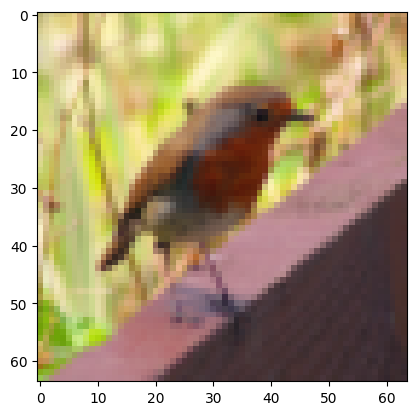

In [21]:
train_set_x, train_set_y, test_set_x, test_set_y, classes = load_dataset()
image_show(10,"train")

y = [1], 它是一张'cat' 图片。


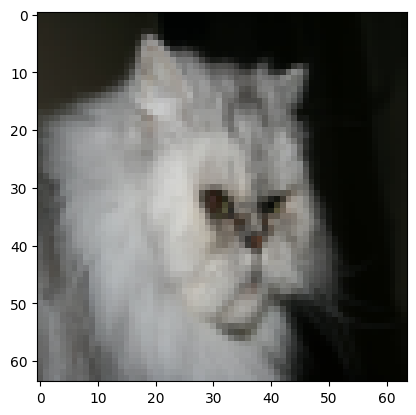

In [22]:
image_show(10,"test")

#### 激活函数

建立猫图分类器的逻辑回归模型过程如下：

猫图分类器中，要实现的是：对于给定的以$n_x$维特征向量$x$表示、标签为$y$的一张图片，估计出这张图片为猫图的概率$\hat{y}$，即：$$\hat{y} = p(y = 1|x), 0 \le \hat{y} \le 1$$

有大量猫图的数据时，考虑采用**线性拟合**的方法，来找到一个$\hat{y}$关于$x$的函数，从而实现这个猫分类器。规定一个$n_x$维向量$w$和一个值$b$作为参数，可得到线性回归的表达式：$${\hat{y} = w^Tx + b}$$

由于$\hat{y}$为概率值，取值范围为$[0,1]$，简单地进行线性拟合，得出的$\hat{y}$可能非常大，还可能为负值。此时，就需要用一个逻辑回归单元来对其值域进行约束。这里以**sigmoid函数**为逻辑回归单元，其表达式为：$$\sigma{(z)} = \frac{1}{1+e^{-z}}$$

函数图像为：

![sigmoid函数](https://raw.githubusercontent.com/Hugsy19/Picbed/master/img/20210411120652.png)

从中可以看出，sigmoid函数具有如下性质：
* 当$z$趋近于正无穷大时，$\sigma{(z)} = 1$;
* 当$z$趋近于负无穷大时，$\sigma{(z)} = 0$;
* 当$z = 0$时，$\sigma{(z)} = 0.5$。

所以可以用sigmoid函数来约束$\hat{y}$的值域，得到该分类器的Logistic回归模型：$${ \hat{y} = σ(w^Tx + b) = \frac{1}{1+e^{-(w^Tx + b)}}}$$

In [26]:
#sigmoid函数
def sigmoid(z):
    s = 1/(1+np.exp(-z))
    return s

#初始化参数w,b
def initialize_with_zeros(dim):
    w = np.zeros((dim,1)) #w为一个dim*1矩阵
    b = 0    
    return w, b

#### 成本函数

建立好逻辑回归模型后，接下来要考虑的是如何利用我们的训练集数据，找到该模型中的两个参数$w$和$b$的最优解。

为了训练逻辑回归模型中的参数w和b，使得输出值$\hat{y}$与真实值y尽可能一致，即尽可能准确地判断一张图是否为猫，需要定义一个成本函数（Cost Function）作为衡量的标准。

单个样本的预测值（${\hat y}^{(i)}$）与其真实值（$y^{(i)}$）之间的误差大小用损失函数（Loss Function）来衡量。平方误差（Square Loss）就是一种常用的损失函数，其表达式为：$${\mathcal{L}(\hat y,y)=\frac{1}{2}(\hat y-y)^2}$$

但逻辑回归中，一般不采用这个损失函数，因为在训练参数过程中，使用这个损失函数将得到一个非凸函数而存在很多个局部最优解，使得后面可能无法使用梯度下降（Gradient Descent）来得到我们想要的最优解。

对这个Logistic回归模型，希望能够满足如下条件概率：
$$p(y|x) = \begin{cases} \hat{y},  & \text{$(y=1)$} \\\ 1 - \hat{y}, & \text{$(y=0)$} \end{cases}$$

将上下两个式子合二为一，可写成：$$p(y|x) = \hat{y}^y (1 - \hat{y})^{(1 - y)} $$

对两边取对数，进一步化简为：$$log\ p(y|x) = ylog\ \hat y+(1-y)log\ (1-\hat y) $$

我们希望$p(y|x)$的值越大越好，而损失越小越好。所以为上式添上负号，就可以将它作为一个损失函数，这便是应用很广的交叉熵（Cross Entropy）损失函数，表达式为：$${\mathcal{L}(\hat y,y)=-[ylog\ \hat y+(1-y)log\ (1-\hat y)]}$$

交叉熵损失函数有如下性质：
* 当$y^{(i)}=1$时，${\mathcal{L}({\hat y}^{(i)},y^{(i)})=-log\ {\hat y}^{(i)}}$，意味着损失越小，$\hat{y}$越接近于1；
* 当$y^{(i)}=0$时，${\mathcal{L}({\hat y}^{(i)},y^{(i)})=-log\ (1-{\hat y}^{(i)})}$，意味着损失越大，$\hat{y}$越接近0。

对m个训练样本整体的成本函数，可以使用数理统计中的参数估计方法之一--最大似然估计法（Maximum Likelihood Estimation）推导出来的。

假设所有训练样本独立同分布，则它们的联合概率为所有样本概率的乘积，得到似然函数为:
$$P (x) = \prod_{i=1}^m p(y^{(i)}|x^{(i)})$$

两边取对数有：
$$log\ P(x) = \sum_{i=1}^m log\ p(y^{(i)}|x^{(i)}) = - \sum_{i=1}^m \mathcal{L}(\hat{y}^{(i)}, y^{(i)})$$

最大似然估计中的下一步，是求解出一组使得上式取得最大值的 参数。而在这里，由于我们训练模型时，目标是使成本函数最小化，所以不直接使用上式作为成本函数，而将其负号去掉，同时为方便处理数据，而乘上一个常数$1/m$对式子适当进行放缩，最后得到下面的成本函数：
$${J(w,b) = \frac{1}{m} \sum_{i=1}^m \mathcal{L}({\hat y}^{(i)}, y^{(i)}) = - \frac{1}{m} \sum_{i=1}^m [ylog\ \hat y+(1-y)log\ (1-\hat y)]}$$

In [27]:
#计算Y_hat,成本函数J以及dw，db
def propagate(w, b, X, Y):
    m = X.shape[1] #样本个数
    Y_hat = sigmoid(np.dot(w.T,X)+b)                                     
    cost = -(np.sum(np.dot(Y,np.log(Y_hat).T)+np.dot((1-Y),np.log(1-Y_hat).T)))/m #成本函数

    dw = (np.dot(X,(Y_hat-Y).T))/m
    db = (np.sum(Y_hat-Y))/m

    cost = np.squeeze(cost) #压缩维度    
    grads = {"dw": dw,
             "db": db} #梯度

    return grads, cost

#### 梯度下降

要找到参数的最优解，一般采用梯度下降法。

标量场中某一函数上某一点的梯度，指向该函数在该点处增长最快的方向，函数在该点处沿着该方向变化最快且变化率最大。

在空间坐标中以$w$，$b$为轴，画出的损失函数$J$的图像将类似于下图，要找到函数取得最小值的最优参数，先为$w$和$b$赋一个初始值，正如下图的最上面的红点。

![J(w,b)图像](https://raw.githubusercontent.com/Hugsy19/Picbed/master/img/20210411120752.png)

对逻辑回归模型，因为成本函数是凸函数，无论参数的初始值是多少，最后总能到达同一个点或大致相同的点，所以几乎任何初始化方法都有效，于是通常将参数直接初始化为0。

所谓的梯度下降，就是从起始点开始，试图每次都沿最陡峭的下降方向下坡，尽可能快地到达最低点即凸函数取得最小值的点，而下坡的方向便是各点上的梯度值。

![J(w,b)二维图像](https://raw.githubusercontent.com/Hugsy19/Picbed/master/img/20210411120806.png)

从一个二维上的图像看，函数的导数方向即为梯度方向，下降速度最快。即每经过一次梯度下降，参数$w$、$b$即更新为：$${w = w-\alpha\frac{\partial J(w,b)}{\partial w}}$$
$${b = b-\alpha\frac{\partial J(w,b)}{\partial b}}$$

式中的$\alpha$被称为学习率，通常为一个小于1的值，用于控制梯度下降过程中每一次移动的规格大小，好比于下降时每一次迈步的大小。$\alpha$的不宜太小也不宜过大：太小会使迭代次数增加，容易陷入局部最优解；太大容易错过最优解。

由梯度下降法，由训练数据经过多次迭代，就可以求得使成本函数的取得最小值的参数$w$和$b$，从而建立好逻辑回归模型，实现我们想要的猫图分类器。

In [28]:
# 梯度下降找出最优解
def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost = False):#num_iterations-梯度下降次数 learning_rate-学习率，即参数ɑ
    costs = [] #记录成本值

    for i in range(num_iterations): #循环进行梯度下降
        grads, cost = propagate(w,b,X,Y)
        dw = grads["dw"]
        db = grads["db"]

        w = w - learning_rate*dw
        b = b - learning_rate*db

        if i % 100 == 0: #每100次记录一次成本值
            costs.append(cost)

        if print_cost and i % 100 == 0: #打印成本值
            print ("循环%i次后的成本值: %f" %(i, cost))

    params = {"w": w,
              "b": b} #最终参数值

    grads = {"dw": dw,
             "db": db}#最终梯度值

    return params, grads, costs

#### 实现整个识别器

In [29]:
#预测出结果
def predict(w, b, X):
    m = X.shape[1] #样本个数
    Y_prediction = np.zeros((1,m)) #初始化预测输出
    w = w.reshape(X.shape[0], 1) #转置参数向量w

    Y_hat = sigmoid(np.dot(w.T,X)+b) #最终得到的参数代入方程

    for i in range(Y_hat.shape[1]):
        if Y_hat[:,i]>0.5:
            Y_prediction[:,i] = 1
        else:
            Y_prediction[:,i] = 0

    return Y_prediction

In [30]:
# 建立整个预测模型
def model(X_train, Y_train, X_test, Y_test, num_iterations = 2000, learning_rate = 0.5, print_cost = False): #num_iterations-梯度下降次数 learning_rate-学习率，即参数ɑ
    w, b = initialize_with_zeros(X_train.shape[0]) #初始化参数w，b

    parameters, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost) #梯度下降找到最优参数

    w = parameters["w"]
    b = parameters["b"]

    Y_prediction_train = predict(w, b, X_train) #训练集的预测结果
    Y_prediction_test = predict(w, b, X_test) #测试集的预测结果

    train_accuracy = 100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100 #训练集识别准确度
    test_accuracy = 100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100 #测试集识别准确度

    print("训练集识别准确度: {} %".format(train_accuracy))
    print("测试集识别准确度: {} %".format(test_accuracy))

    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test,
         "Y_prediction_train" : Y_prediction_train,
         "w" : w,
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations}

    return d

In [31]:
#初始化数据
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

m_train = train_set_x_orig.shape[0] #训练集中样本个数
m_test = test_set_x_orig.shape[0] #测试集总样本个数
num_px = test_set_x_orig.shape[1] #图片的像素大小

train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0],-1).T #原始训练集的设为（12288*209）
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0],-1).T #原始测试集设为（12288*50）

train_set_x = train_set_x_flatten/255. #将训练集矩阵标准化
test_set_x = test_set_x_flatten/255. #将测试集矩阵标准化

d = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations = 2000, learning_rate = 0.005, print_cost = True)

循环0次后的成本值: 0.693147
循环100次后的成本值: 0.584508
循环200次后的成本值: 0.466949
循环300次后的成本值: 0.376007
循环400次后的成本值: 0.331463
循环500次后的成本值: 0.303273
循环600次后的成本值: 0.279880
循环700次后的成本值: 0.260042
循环800次后的成本值: 0.242941
循环900次后的成本值: 0.228004
循环1000次后的成本值: 0.214820
循环1100次后的成本值: 0.203078
循环1200次后的成本值: 0.192544
循环1300次后的成本值: 0.183033
循环1400次后的成本值: 0.174399
循环1500次后的成本值: 0.166521
循环1600次后的成本值: 0.159305
循环1700次后的成本值: 0.152667
循环1800次后的成本值: 0.146542
循环1900次后的成本值: 0.140872
训练集识别准确度: 99.04306220095694 %
测试集识别准确度: 70.0 %


#### 结果分析

训练集识别准确率接近100％，测试集的准确率有70％。由于训练使用的小数据集，而且逻辑回归是线性分类器，所以这个结果对于这个简单的模型实际上还是不错。

使用mathplotlib画出学习曲线：

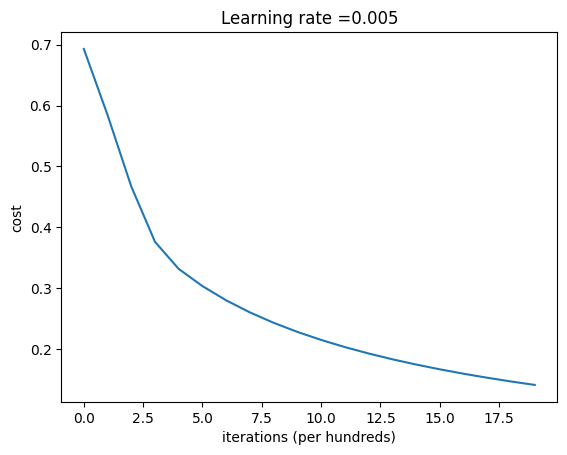

In [32]:
costs = np.squeeze(d['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate =" + str(d["learning_rate"]))
plt.show()

对比学习率不同时的学习曲线：

学习率: 0.01
训练集识别准确度: 99.52153110047847 %
测试集识别准确度: 68.0 %

-------------------------------------------------------

学习率: 0.001
训练集识别准确度: 88.99521531100478 %
测试集识别准确度: 64.0 %

-------------------------------------------------------

学习率: 0.0001
训练集识别准确度: 68.42105263157895 %
测试集识别准确度: 36.0 %

-------------------------------------------------------



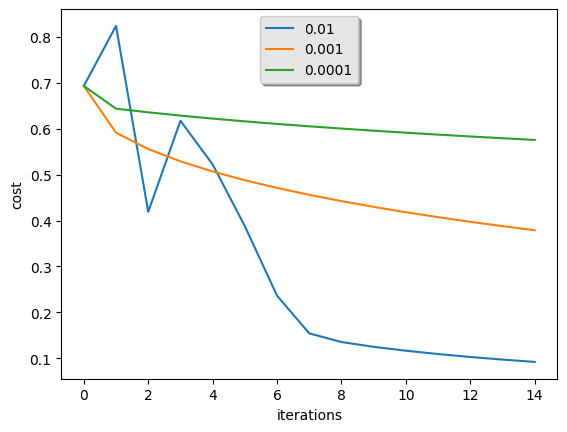

In [33]:
learning_rates = [0.01, 0.001, 0.0001]
models = {}
for i in learning_rates:
    print ("学习率: " + str(i))
    models[str(i)] = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations = 1500, learning_rate = i, print_cost = False)
    print ('\n' + "-------------------------------------------------------" + '\n')

for i in learning_rates:
    plt.plot(np.squeeze(models[str(i)]["costs"]), label= str(models[str(i)]["learning_rate"]))

plt.ylabel('cost')
plt.xlabel('iterations')

legend = plt.legend(loc='upper center', shadow=True)
frame = legend.get_frame()
frame.set_facecolor('0.90')
plt.show()